In [57]:
!pip install pypdf #to convert pdfs to text


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [81]:
!pip install wordninja #to separate long joined words that resulted due to the conversion


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/541.6 kB ? eta -:--:--
     ---------------------------------------- 541.6/541.6 kB 4.4 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for wordninja: filename=wordninja-2.0.0-py3-none-any.whl size=541559 sha256=faced7c507dd69f03199e6f1e13461c73d3f5b9edd9c6bc12983e3b2177e78ba
  Stored in directory: c:\users\lenovo\appdata\local\pip\cache\wheels\e6\66\9c\712044a983337f5d44f90abcd244bd4b8ad28ee64750404b50
Successfully built wordninja


In [175]:
!pip install scikit-learn # to implement PCA


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [58]:
import numpy as np
import random

# Task 1: Dataset Preprocessing

In [9]:
from pathlib import Path
from pypdf import PdfReader
# Paths to downloaded pdfs
pdf_folder = Path(r"C:\Users\LENOVO\Documents\IITJ Projects\NLU2\pdfs")
# Paths to store txt file
txt_folder = Path(r"C:\Users\LENOVO\Documents\IITJ Projects\NLU2\txt")

txt_folder.mkdir(parents=True, exist_ok=True)

# For loop  to convert all pdf files in the 'pdfs' folder to text file
for pdf_file in pdf_folder.glob("*.pdf"):
    
    # Opens the PDF file using PdfReader
    reader = PdfReader(str(pdf_file))
    
    # List to store text from pdf
    full_text = []

    # To go through each page in the PDF
    for page in reader.pages:
        
        # extracts text from the current page
        text = page.extract_text()
        
        # Only adds the text if something was extracted incase some pages are empty or unreadable
        if text:
            full_text.append(text)

    # Creates the output file path with the same name but .txt extension
    output_file = txt_folder / f"{pdf_file.stem}.txt"

    # Opens the output text file in write mode with UTF-8 encoding
    with open(output_file, "w", encoding="utf-8") as f:
        
        # Joins all page texts with newline and writes to file
        f.write("\n".join(full_text))

    # Prints which file got converted
    print(f"Converted: {pdf_file.name} -> {output_file.name}")

Converted: 1_Academic_Regulations_Final_03_09_2019.pdf -> 1_Academic_Regulations_Final_03_09_2019.txt
Converted: 2.1_notification_26102020.pdf -> 2.1_notification_26102020.txt
Converted: 2_Academic_Regulations_Final_03_09_2019.pdf -> 2_Academic_Regulations_Final_03_09_2019.txt
Converted: 3_Academic_Regulations_Final_03_09_2019.pdf -> 3_Academic_Regulations_Final_03_09_2019.txt
Converted: 4_Regulation_PG_2022-onwards_20022023.pdf -> 4_Regulation_PG_2022-onwards_20022023.txt
Converted: 5_Circular_IITJ_OA_C_2021-22_21_122_20.01.2022.pdf -> 5_Circular_IITJ_OA_C_2021-22_21_122_20.01.2022.txt
Converted: 6_2024-04-17-661f605b54457-1713332315.pdf -> 6_2024-04-17-661f605b54457-1713332315.txt
Converted: 7.1_Circular_51Circular-No.-IITJOAACircular2024-2551682-dated-08-July-2024.pdf -> 7.1_Circular_51Circular-No.-IITJOAACircular2024-2551682-dated-08-July-2024.txt
Converted: 7.2_Circular_52Circular-No.-IITJOAACircular2024-2552683-dated-08-July-2024.pdf -> 7.2_Circular_52Circular-No.-IITJOAACircular

### Preprocessing the .txt files collected

In [10]:
import re


def preprocess(text):
    '''Function to preprocess files'''
    text = text.lower() # convertign to lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # removing punctuation and numbers and other symbols
    tokens = text.split() # each word = 1 token
    return tokens

### Combining files and calling preprocess function

In [19]:
from pathlib import Path

# Defining the folder path that contains all extracted .txt files
# Using Path object for easy file handling and iteration

txt_folder = Path(r"C:\Users\LENOVO\Documents\IITJ Projects\NLU2\txt")



# Initializing an empty list to store all tokens from all files. This will form our final corpus
corpus = []



# Loop through all .txt files in the folder
# For each file:
#   1. Open and read the content
#   2. Preprocess the text
#   3. Add tokens to the corpus

for file in txt_folder.glob("*.txt"):
    with open(file, 'r', encoding='utf-8') as f:
        text = f.read()  # read full file content
        
        tokens = preprocess(text)  # clean and tokenize
        
        corpus += tokens  # add tokens to the main corpus

In [20]:
# Saving cleaned corpus as one clean file

cleaned_text = " ".join(corpus)

#path of the corpus
output_path = Path(r"C:\Users\LENOVO\Documents\IITJ Projects\NLU2\cleaned_corpus.txt")

#open the file and write
with open(output_path, "w", en.coding="utf-8") as f:
    f.write(cleaned_text)

#print confirmation
print("Cleaned corpus saved!")

Cleaned corpus saved!


## Reporting dataset statistics

In [22]:
# Dataset Statistics
# Printing the total number of documents, total tokens and size of the vocabulary

# Total number of tokens (all words including repetitions)
total_tokens = len(corpus)

# Vocabulary size (unique words only)
vocab_size = len(set(corpus))

# Display dataset statistics
print(f"Total tokens: {total_tokens}")
print(f"Vocabulary size: {vocab_size}")

total_docs = len(files) # total documents
print(f"Total number of documents: {total_docs}")



Total tokens: 191186
Vocabulary size: 11899
Total number of documents: 48


In [61]:
# to see the most frequent and least frequent words
from collections import Counter

words = " ".join(corpus).split()
word_freq = Counter(words)

# Top 10 most common
print(word_freq.most_common(10))

# Least common (rare words)
print(word_freq.most_common()[-10:])

[('the', 11625), ('of', 7743), ('and', 5351), ('a', 4319), ('for', 3995), ('to', 3926), ('in', 3573), ('be', 2603), ('student', 1940), ('by', 1628)]
[('dignity', 1), ('unfair', 1), ('advantage', 1), ('admired', 1), ('furthering', 1), ('sincere', 1), ('continually', 1), ('upholding', 1), ('utmost', 1), ('confidentiality', 1)]


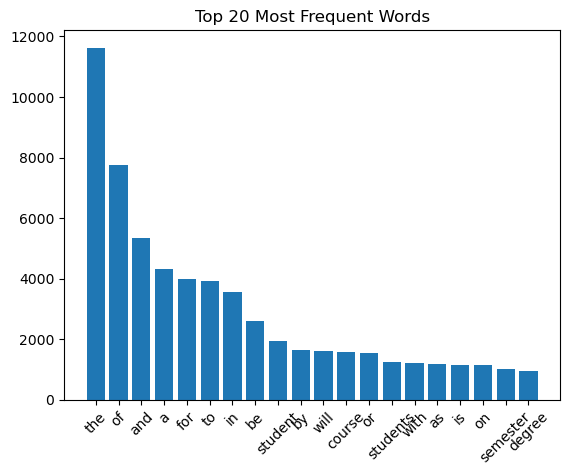

In [62]:
import matplotlib.pyplot as plt

top_words = word_freq.most_common(20)
words, counts = zip(*top_words)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.show()

In [67]:
# number of words that appear only once

rare_words = [word for word, freq in word_freq.items() if freq == 1]

print("Number of rare words:", len(rare_words))

Number of rare words: 6735


In [79]:
print(rare_words[:10])

['iitjoffice', 'notification', 'clause', 'progranmme', 'acdemics', 'regulationsfor', 'aredesignedtodevelopthe', 'creationacross', 'disciplinesobliteratingtraditionalboundariesbetweensciencehumanitiessocial', 'toproducequalityprofessionals']


To separate joined words like 'toproducequalityprofessionals', using wordninja library

In [210]:
# using wordninja to split 

from wordninja import split

cleaned_corpus = [] # new corpus to store the split words
#Adding a dictionary based filter
def smart_split(word):
    parts = split(word)
    return " ".join(parts)

for doc in corpus:
    words = doc.split()
    fixed = [smart_split(w) if len(w) > 12 else w for w in words]
    cleaned_corpus.append(" ".join(fixed))

In [132]:
# number of words that appear only once in the cleaned corpus after splitting joined words

words = " ".join(cleaned_corpus).split()
word_freq = Counter(words)

rare_words = [word for word, freq in word_freq.items() if freq == 1]

print("Number of rare words:", len(rare_words))

print(rare_words[:50])

Number of rare words: 4444
['iitjoffice', 'notification', 'clause', 'progranmme', 'acdemics', 'ort', 'thesubject', 'thesenateof', 'andrules', 'modications', 'fromtheendof', 'afresh', 'acerticate', 'bede', 'theappeal', 'mayaddor', 'dropcourses', 'withapproval', 'aperiodof', 'moreweeks', 'duringa', 'mayo', 'witha', 'ofcourses', 'seetable', 'ofacademics', 'noteexamples', 'rm', 'artsothers', 'basisof', 'crm', 'crmsc', 'crmtech', 'withcgpamsc', 'crphd', 'levelcourse', 'isn', 'aliz', 'minimumof', 'thecourse', 'runningas', 'providedthat', 'thecourseis', 'acoreor', 'betherefor', 'meannot', 'aninstructor', 'tocanopt', 'topicof', 'coursenot']


In [100]:
output_path = r"C:\Users\LENOVO\Documents\IITJ Projects\NLU2\new_corpus.txt"

with open(output_path, "w", encoding="utf-8") as f:
    for doc in cleaned_corpus:
        clean_doc = " ".join(doc.split())  # removes extra spaces/newlines
        f.write(clean_doc + "\n\n")  # separate documents

print("Saved cleaned corpus to one file!")

Saved cleaned corpus to one file!


In [211]:
#Checking the most and least frequent words again, after splitting the joined words 
words = " ".join(cleaned_corpus).split()
word_freq = Counter(words)

# Top 10 most common
print(word_freq.most_common(10))

# Least common (rare words)
print(word_freq.most_common()[-10:])

[('the', 12134), ('of', 7983), ('and', 5598), ('a', 4494), ('for', 4111), ('to', 4082), ('in', 3778), ('be', 2666), ('student', 1994), ('by', 1672)]
[('dignity', 1), ('unfair', 1), ('advantage', 1), ('admired', 1), ('furthering', 1), ('sincere', 1), ('continually', 1), ('upholding', 1), ('utmost', 1), ('confidentiality', 1)]


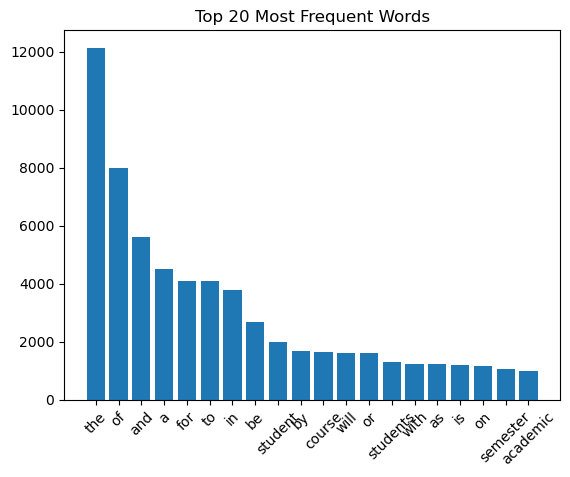

In [212]:
#Plotting 20 most frequest words to check for changes again
import matplotlib.pyplot as plt

top_words = word_freq.most_common(20)
words, counts = zip(*top_words)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.show()

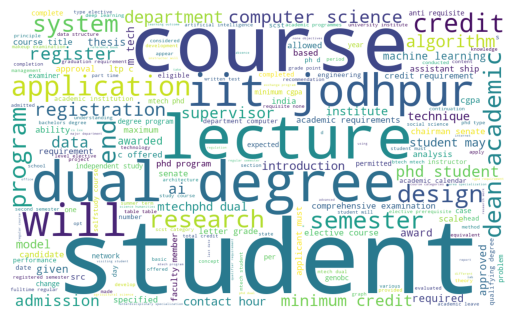

In [109]:
# Plotting Word Cloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(cleaned_corpus)

wc = WordCloud(width=1000, height=600, background_color='white').generate(text)

plt.imshow(wc)
plt.axis('off')
plt.show()

# Task 2: Model Training

Trained two Word2Vec models: 

Continuous Bag of Words (CBOW) and Skip-gram with Negative Sampling. 

For each model, experimented with: 

(i) Embedding dimension

(ii) Context window size

(iii) Number of negative samples.

### Word2Vec with CBOW

In [86]:
# Step 1: Converting corpus(list of words) into a pair (context_words, target_word)

from collections import deque

'''Function: generate_cbow_data
Purpose: Converts a list of tokens into CBOW training samples
Inputs:
 1. corpus : corpus created earlier
 2. window_size : number of words on EACH side
Output: List of (context, target) pairs'''

def generate_cbow_data(corpus, window_size):
    data = []
    
    # total context size = 2 * window_size
    for i in range(window_size, len(corpus) - window_size):
        
        context = []
        
        # collect words before target
        for j in range(i - window_size, i):
            context.append(corpus[j])
        
        # collect words after target
        for j in range(i + 1, i + window_size + 1):
            context.append(corpus[j])
        
        target = corpus[i]
        
        data.append((context, target))
    
    return data


In [87]:
# Building vocabulary
# mpping words to indices

vocab = list(set(corpus))
vocab_size = len(vocab)

# word_to_ix: word -> index
word_to_ix = {word: i for i, word in enumerate(vocab)}
# ix_to_word: index -> word
ix_to_word = {i: word for word, i in word_to_ix.items()}

In [88]:
# function to convert words to indices
def encode_data(data, word_to_ix):
    encoded = []
    
    # Loops over each (context, target) pair
    for context, target in data:
        
        # Converts context words to indices
        context_idx = [word_to_ix[w] for w in context]
        
        # Converts target word to index
        target_idx = word_to_ix[target]
        
        # Stores the encoded pair
        encoded.append((context_idx, target_idx))
    
    # Returns all encoded data
    return encoded

In [89]:
# generating CBOW training data

def generate_cbow_data(corpus, window_size):
    data = []

    for i in range(window_size, len(corpus) - window_size):
        
        context = []
        
        # left context
        for j in range(i - window_size, i):
            context.append(word_to_ix[corpus[j]])   # convert to index
        
        # right context
        for j in range(i + 1, i + window_size + 1):
            context.append(word_to_ix[corpus[j]])   # convert to index
        
        target = word_to_ix[corpus[i]]  # convert target too
        
        data.append((context, target))
    
    return data

In [90]:
# Initializing parameters
# W1 = input embedding matrix
# W2 = output embedding matrix

def initialize_model(vocab_size, embedding_dim):
    
    # Input embeddings
    W1 = np.random.randn(vocab_size, embedding_dim) * 0.01
    
    # Output embeddings
    W2 = np.random.randn(embedding_dim, vocab_size) * 0.01
    
    return W1, W2

In [91]:
# Sigmoid function for negative sampling

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# function for negative sampling
def get_negative_samples(vocab_size, target, num_negatives):
    negatives = []
    # Keep sampling until we have enough negatives
    while len(negatives) < num_negatives:
        neg = random.randint(0, vocab_size - 1)   # Pick a random word index
        if neg != target: # Make sure it's not the target word
            negatives.append(neg)
    
    return negatives #list of negative samples

### CBOW with negative sampling

In [92]:
# Forward passs of CBOW
# Takes embeddings of context words
# Averages them to context vector
# Computes score with target

def forward(context, W1):
    
    # get embeddings for all context words
    context_embeddings = W1[context]   # shape: (context_size, embedding_dim)
    
    # average them
    v = np.mean(context_embeddings, axis=0)  # shape: (embedding_dim,)
    
    return v

In [93]:
# Loss and Backpropagation

# Loss in negative sampling:
# For target word maximize sigmoid
# For negative words minimize sigmoid

def train_step(context, target, W1, W2, lr, num_negatives):
    
    # forward pass
    v = forward(context, W1)   # context vector
    
    # get negative samples
    negatives = get_negative_samples(vocab_size, target, num_negatives)
    
    loss = 0
    
    # gradients initilized for context vector
    grad_v = np.zeros_like(v)
    
    # Positive sample
    # score between context and true target 
    score_pos = np.dot(v, W2[:, target])
    sig_pos = sigmoid(score_pos)
    
    # Loss for positive sample
    loss -= np.log(sig_pos + 1e-9)
    
    # Gradient for positive sample
    grad = sig_pos - 1  # derivative
    
    # Update gradients and weights
    grad_v += grad * W2[:, target]
    W2[:, target] -= lr * grad * v
    

    # Negative samples
    for neg in negatives:
        # Score with negative word
        score_neg = np.dot(v, W2[:, neg])
        sig_neg = sigmoid(score_neg)
        
        # Loss for negative sample
        loss -= np.log(1 - sig_neg + 1e-9)
        
        # Gradient for negative sample
        grad = sig_neg  # derivative
        
        # Update gradients and weights
        grad_v += grad * W2[:, neg]
        W2[:, neg] -= lr * grad * v
    
    # Backprop to input embedding (W1)
    for word in context:
        W1[word] -= lr * grad_v / len(context)
    
    return loss # Return total loss

In [94]:
# checking if the words are converted to indices
data = generate_cbow_data(corpus, 2)

print(data[0])

([10472, 1960, 4687, 9453], 6684)


In [95]:
# Training loop

def train_cbow(training_data, vocab_size, embedding_dim, lr, epochs, num_negatives):
    
    # initialize weights
    W1, W2 = initialize_model(vocab_size, embedding_dim)
    
    # Loops over epochs
    for epoch in range(epochs):
        total_loss = 0 # Initialize loss to 0
        
        # Goes through each training example
        for context, target in training_data:
            # Performs one training step
            loss = train_step(context, target, W1, W2, lr, num_negatives)
            total_loss += loss
        
        # To print loss for this epoch
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")
    
    return W1, W2 # Return learned embeddings

### Experiments

In [135]:
# trying out different combinations for experimentation
embedding_dims = [50, 100, 150]
window_sizes = [2, 4, 6]
negative_samples_list = [2, 5, 6]

# looping over all configs
for emb_dim in embedding_dims:
    for window in window_sizes:
        for neg in negative_samples_list:
            
            # to keep track of what's running
            print(f"\nRunning: dim={emb_dim}, window={window}, neg={neg}")
            
            # build CBOW training data for this window size
            data = generate_cbow_data(corpus, window)
            
            # train model with current settings
            W1, W2 = train_cbow(
                data,
                vocab_size,
                embedding_dim=emb_dim,  # size of embeddings
                lr=0.01,                 # learning rate fixed for now
                epochs=2,                # keeping it low because takes a lot of time
                num_negatives=neg        # number of negative samples
            )


Running: dim=50, window=2, neg=2
Epoch 1, Loss: 380582.3372
Epoch 2, Loss: 290553.1001

Running: dim=50, window=2, neg=5
Epoch 1, Loss: 743628.2293
Epoch 2, Loss: 403267.0913

Running: dim=50, window=2, neg=6
Epoch 1, Loss: 843374.9857
Epoch 2, Loss: 417390.4087

Running: dim=50, window=4, neg=2
Epoch 1, Loss: 372287.6722
Epoch 2, Loss: 271058.8561

Running: dim=50, window=4, neg=5
Epoch 1, Loss: 726255.6420
Epoch 2, Loss: 349117.3579

Running: dim=50, window=4, neg=6
Epoch 1, Loss: 824723.8600
Epoch 2, Loss: 359374.2855

Running: dim=50, window=6, neg=2
Epoch 1, Loss: 372304.8777
Epoch 2, Loss: 269191.2034

Running: dim=50, window=6, neg=5
Epoch 1, Loss: 720594.9822
Epoch 2, Loss: 330951.0344

Running: dim=50, window=6, neg=6
Epoch 1, Loss: 811587.9835
Epoch 2, Loss: 336568.2687

Running: dim=100, window=2, neg=2
Epoch 1, Loss: 376777.5733
Epoch 2, Loss: 284727.6129

Running: dim=100, window=2, neg=5
Epoch 1, Loss: 735164.1794
Epoch 2, Loss: 395631.9202

Running: dim=100, window=2, n

In [136]:
# Since large window size gives less loss and increasing negative samples leads to higher loss, performing 1 moore experiment with more number of epochs
# Final run with chosen hyperparameters
embedding_dims = [100]
window_sizes = [6]
negative_samples_list = [1]

# Still keeping the loop structure for consistency
for emb_dim in embedding_dims:
    for window in window_sizes:
        for neg in negative_samples_list:
            
            # Printing what’s running
            print(f"\nRunning: dim={emb_dim}, window={window}, neg={neg}")
            
            # To generate data using selected window size
            data = generate_cbow_data(corpus, window)
            
            # Training final model with more epochs this time
            W1, W2 = train_cbow(
                data,
                vocab_size,
                embedding_dim=emb_dim,  # fixed embedding size
                lr=0.01,                 # same learning rate
                epochs=6,                # increased epochs for better learning
                num_negatives=neg        # minimal negative sampling
            )


Running: dim=100, window=6, neg=1
Epoch 1, Loss: 239071.8705
Epoch 2, Loss: 180791.5395
Epoch 3, Loss: 152554.8486
Epoch 4, Loss: 135734.7071
Epoch 5, Loss: 127072.6340
Epoch 6, Loss: 122011.7120


### Skip-gram with negative sampling

given the center word, predicts it's context words

In [137]:
# generating skip-gram training data

# Function creates (center, context) pairs
#
# Example:
#   window_size = 2
#   "the cat sat on mat"
#   center="sat"
#   context=["the","cat","on","mat"]
#   pairs:
#   (sat, the), (sat, cat), (sat, on), (sat, mat)


def generate_skipgram_data(corpus, window_size):
    data = []

    # go through each word (skip edges)
    for i in range(window_size, len(corpus) - window_size):
        
        # current word -> center
        center = word_to_ix[corpus[i]]
        
        # words to the left of center
        for j in range(i - window_size, i):
            context = word_to_ix[corpus[j]]
            data.append((center, context))  # (center, context)
        
        # words to the right of center
        for j in range(i + 1, i + window_size + 1):
            context = word_to_ix[corpus[j]]
            data.append((center, context))  # (center, context)
    
    # return all pairs
    return data

In [138]:
# Initializing parameters

# W1: input embeddings (center word vectors)
# W2: output embeddings (context word vectors)
#reusing initialize_model(vocab_size, embedding_dim) which was used in CBOW

# Reusing get_negative_samples(vocab_size, target, num_negatives)

In [139]:
# Forward + Loss  + Backpropagation
# For each(center, context):
#  -> maximize sigmoid(center . context)
#  -> minimize sigmoid(center . negative words)

def train_step_skipgram(center, context, W1, W2, lr, num_negatives):
    
    # store embedding of the center word
    v_c = W1[center]
    loss = 0
    
    # Pick some random negative samples (words not equal to context)
    negatives = get_negative_samples(vocab_size, context, num_negatives)
    
    # collect gradients for the center word
    grad_vc = np.zeros_like(v_c)
    

    # ----- positive pair (center -> actual context) -----
    
    # Similarity score between center and true context
    score_pos = np.dot(v_c, W2[:, context])
    sig_pos = sigmoid(score_pos)
    
    # We want this to be high so take -log
    loss -= np.log(sig_pos + 1e-9)
    
    # derivative part (comes from sigmoid + log loss)
    grad = sig_pos - 1
    
    # update gradients and output weights
    grad_vc += grad * W2[:, context]
    W2[:, context] -= lr * grad * v_c
    
    
    # ----- negative samples (push them away) -----
    for neg in negatives:
        
        # score with a wrong/random word
        score_neg = np.dot(v_c, W2[:, neg])
        sig_neg = sigmoid(score_neg)
        
        # we want this to be low so (1 - sigmoid)
        loss -= np.log(1 - sig_neg + 1e-9)
        
        # gradient for negative case
        grad = sig_neg
        
        # update gradients and weights
        grad_vc += grad * W2[:, neg]
        W2[:, neg] -= lr * grad * v_c
    
    # Finally update the center word embedding
    W1[center] -= lr * grad_vc
    
    return loss

In [140]:
# Training loop
def train_skipgram(training_data, vocab_size, embedding_dim, lr, epochs, num_negatives):
    
    # initialize embeddings (input and output)
    W1, W2 = initialize_model(vocab_size, embedding_dim)
    
    # loop over epochs
    for epoch in range(epochs):
        total_loss = 0
        
        # go through each (center, context) pair
        for center, context in training_data:
            
            # one training step
            loss = train_step_skipgram(center, context, W1, W2, lr, num_negatives)
            total_loss += loss
        
        # print progress after each epoch
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")
    
    # return learned embeddings
    return W1, W2

In [142]:
# experiments

embedding_dims = [50, 100, 150]
window_sizes = [2, 4, 6]
negative_samples_list = [2, 5, 8]


# experiment loop:
for emb_dim in embedding_dims:
    for window in window_sizes:
        
        # Generate training data for this window size
        data = generate_skipgram_data(corpus, window)
        
        for neg in negative_samples_list:
            
            print(f"\nRunning Skip-gram: dim={emb_dim}, window={window}, neg={neg}")
            
            # Train model
            W1, W2 = train_skipgram(
                data,
                vocab_size,
                embedding_dim=emb_dim,
                lr=0.01,
                epochs=2,
                num_negatives=neg
            )


Running Skip-gram: dim=50, window=2, neg=2
Epoch 1, Loss: 1206476.6026
Epoch 2, Loss: 796414.1717

Running Skip-gram: dim=50, window=2, neg=5
Epoch 1, Loss: 1995226.3021
Epoch 2, Loss: 1104813.8337

Running Skip-gram: dim=50, window=2, neg=8
Epoch 1, Loss: 2502470.3039
Epoch 2, Loss: 1274246.9369

Running Skip-gram: dim=50, window=4, neg=2
Epoch 1, Loss: 1963455.2331
Epoch 2, Loss: 1321889.5908

Running Skip-gram: dim=50, window=4, neg=5
Epoch 1, Loss: 3003590.5614
Epoch 2, Loss: 1842970.0608

Running Skip-gram: dim=50, window=4, neg=8
Epoch 1, Loss: 3631997.3136
Epoch 2, Loss: 2143962.7465

Running Skip-gram: dim=50, window=6, neg=2
Epoch 1, Loss: 2599579.3416
Epoch 2, Loss: 1828915.1317

Running Skip-gram: dim=50, window=6, neg=5
Epoch 1, Loss: 3856579.9369
Epoch 2, Loss: 2549312.4925

Running Skip-gram: dim=50, window=6, neg=8
Epoch 1, Loss: 4593851.9056
Epoch 2, Loss: 2959738.2954

Running Skip-gram: dim=100, window=2, neg=2
Epoch 1, Loss: 1201187.4990
Epoch 2, Loss: 794214.3103



In [143]:
# training one final skip-gram model with chosen hyperparameters
embedding_dim = 100
window = 4
neg = 2

# Generating data
data = generate_skipgram_data(corpus, 4)

#training the final model
W1_sg, W2_sg = train_skipgram(
    data,
    vocab_size,
    embedding_dim=100,
    lr=0.01,          #Same learning rate as CBOW
    epochs=3,         #Increased number of epochs
    num_negatives=5
)

Epoch 1, Loss: 2983372.4558
Epoch 2, Loss: 1837335.2343
Epoch 3, Loss: 1678918.4038


# Task 3: SEMANTIC ANALYSIS
Using cosine similarity:
1. Reporting the top 5 nearest neighbors for the words:
research,
student,
phd, 
exam

2. Performing analogy experiments, such as:
UG:BTech::PG:?

### Functions for computing cosine similarity

In [146]:
# Function to compute similarity between two vectors
def cosine_similarity(vec1, vec2):
    
    # dot product to measure alignment
    dot = np.dot(vec1, vec2)
    
    # magnitude of each vector
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    
    # divide by product of norms to normalize
    return dot / (norm1 * norm2 + 1e-9)  # small value to avoid divide by zero

In [147]:
# Funciton to find 'n' most similar words
def get_nearest_neighbours(word, embeddings, top_n=5):
    
    # check if the word exists
    if word not in word_to_ix:
        print(f"{word} not in vocabulary")
        return []
    
    # get vector of the input word
    target_vec = embeddings[word_to_ix[word]]
    
    similarities = []
    
    # compare with every other word
    for other_word in vocab:
        
        # skip the same word
        if other_word == word:
            continue
        
        # get vector of the other word
        other_vec = embeddings[word_to_ix[other_word]]
        
        # compute similarity
        sim = cosine_similarity(target_vec, other_vec)
        
        # store (word, similarity)
        similarities.append((other_word, sim))
    
    # sort by similarity (highest first)
    similarities.sort(key=lambda x: x[1], reverse=True)
    
    # return top N closest words
    return similarities[:top_n]

In [148]:
# For both CBOW and Skip-gram words we have to check for
words_to_check = ["research", "student", "phd", "exam"]

In [149]:
# embeddings for CBOW
embeddings_CBOW = W1
# embeddings for Skipgram
embeddings_SG = W1_sg

In [153]:
# 1.1 Cosine Similarity for CBOW


for word in words_to_check:
    
    # print header
    print(f"\nCBOW Nearest neighbours for '{word}':")
    
    # get similar words using CBOW embeddings
    neighbours_CBOW = get_nearest_neighbours(word, embeddings_CBOW)
    
    # print neighbour with its similarity score
    for w, score in neighbours_CBOW:
        print(f"{w} : {score:.4f}")  # rounded to 4 decimal places


CBOW Nearest neighbours for 'research':
faculty : 0.9394
areas : 0.9311
challenges : 0.9280
knowledge : 0.9256
ability : 0.9255

CBOW Nearest neighbours for 'student':
who : 0.8755
can : 0.8605
may : 0.8415
an : 0.8402
is : 0.8354

CBOW Nearest neighbours for 'phd':
eligible : 0.9462
semesters : 0.9454
allowed : 0.9436
fellowship : 0.9434
status : 0.9431

CBOW Nearest neighbours for 'exam':
step : 0.9971
applying : 0.9969
scheduled : 0.9967
yet : 0.9966
supplementary : 0.9966


In [157]:
# 1.2 Cosine Similarity for Skip-gram

# Same as before
for word in words_to_check:
    
    # Print header
    print(f"\nSkip-gram Nearest neighbours for '{word}':")
    # get similar words using Skipgram embeddings
    neighbours_SG = get_nearest_neighbours(word, embeddings_SG)
     # print neighbour with its similarity score
    for w, score in neighbours_SG:
        print(f"{w} : {score:.4f}")


Skip-gram Nearest neighbours for 'research':
supervisors : 0.9313
thesis : 0.9163
proposal : 0.9162
ability : 0.9154
through : 0.9151

Skip-gram Nearest neighbours for 'student':
who : 0.8812
can : 0.8530
leave : 0.8339
may : 0.8302
an : 0.8279

Skip-gram Nearest neighbours for 'phd':
programs : 0.9448
admissions : 0.9436
admission : 0.9403
candidates : 0.9399
fees : 0.9391

Skip-gram Nearest neighbours for 'exam':
topic : 0.9973
tests : 0.9971
middle : 0.9970
satisfy : 0.9969
applied : 0.9968


### Functions for analogy

In [163]:
# Analogy: a : b :: c : ?

def analogy(a, b, c, embeddings, topn=5):
    
    # check if any word is missing, if yes then don't continue
    if (a not in word_to_ix or 
        b not in word_to_ix or 
        c not in word_to_ix):
        print("Word not in vocabulary")
        return []
    
    # get vectors for the three words
    veca = embeddings[word_to_ix[a]]
    vecb = embeddings[word_to_ix[b]]
    vecc = embeddings[word_to_ix[c]]
    
    # analogy: b - a + c similar to (king - man + woman ≈ queen)
    target_vector = vecb - veca + vecc
    
    similarities = []
    
    # compare this new vector with every word
    for word in vocab:
        
        # skip input words, we already know them
        if word in [a, b, c]:
            continue
        
        vec = embeddings[word_to_ix[word]]
        
        # see how close it is
        similarity = cosine_similarity(target_vector, vec)
        
        similarities.append((word, similarity))
    
    # sort so most similar words come first
    similarities.sort(key=lambda x: x[1], reverse=True)
    
    # return top matches
    return similarities[:topn]

In [208]:
# 2.1 Analogy experiments for CBOW

print("\nCBOW----------------------")
print("\n UG : BTech :: PG : ?")
print(analogy("ug", "btech", "pg", embeddings_CBOW))

print("\n Student : Study :: Professor : ?")
print(analogy("student", "study", "professor", embeddings_CBOW))

print("\n fulltime : regular :: parttime : ?")
print(analogy("credit", "course", "audit", embeddings_CBOW))

print("\n exam : Test :: Assignment : ?")
print(analogy("exam", "test", "assignment", embeddings_CBOW))

print("\n phd : fellowship :: mtech : ?")
print(analogy("phd", "fellowship", "mtech", embeddings_CBOW))

print("\n phd : candidate :: btech : ?")
print(analogy("phd", "candidate", "btech", embeddings_CBOW))

print("\n lab : research :: campus : ?")
print(analogy("lab", "research", "campus", embeddings_CBOW))

print("\n btech : jee :: mtech : ?")
print(analogy("btech", "jee", "mtech", embeddings_CBOW))

print("\n jee : btech :: gate : ?")
print(analogy("jee", "btech", "gate", embeddings_CBOW))

print("\n credit : course :: audit : ?")
print(analogy("credit", "course", "audit", embeddings_CBOW))


CBOW----------------------

 UG : BTech :: PG : ?
[('cr', 0.9639235780374961), ('specialization', 0.9554751850729635), ('msc', 0.9484742181484579), ('mtech', 0.946213856497763), ('compulsory', 0.9453336309269419)]

 Student : Study :: Professor : ?
[('fractal', 0.6046138282615555), ('lectures', 0.5930926790710422), ('systems', 0.5781140196839832), ('design', 0.5779153042306523), ('melxx', 0.5765906962080877)]

 fulltime : regular :: parttime : ?
[('not', 0.8115008005205356), ('independent', 0.7832392504512931), ('selfstudy', 0.7813985216017959), ('study', 0.7644812151853113), ('coordinator', 0.7590852803147903)]

 exam : Test :: Assignment : ?
[('interview', 0.9899605102159872), ('qualify', 0.9895176952852321), ('ascertaining', 0.9889620065060237), ('jam', 0.9882571430127431), ('integral', 0.988135579110602)]

 phd : fellowship :: mtech : ?
[('humanities', 0.9529596003960544), ('materials', 0.9429267101541826), ('engineering', 0.9427592577666042), ('metallurgical', 0.9368452351167801)

In [209]:
# 2.2 Analogy experiments for Skipgram 

print("\nSkip-gram----------------------")
print("\nUG : BTech :: PG : ?")
print(analogy("ug", "btech", "pg", embeddings_SG))

print("\n Student : Study :: Professor : ?")
print(analogy("student", "study", "professor", embeddings_SG))

print("\n fulltime : regular :: parttime : ?")
print(analogy("credit", "course", "audit", embeddings_SG))

print("\n exam : Test :: Assignment : ?")
print(analogy("exam", "test", "assignment", embeddings_SG))

print("\n phd : fellowship :: mtech : ?")
print(analogy("phd", "fellowship", "mtech", embeddings_SG))

print("\n phd : candidate :: btech : ?")
print(analogy("phd", "candidate", "btech", embeddings_SG))

print("\n lab : research :: campus : ?")
print(analogy("lab", "research", "campus", embeddings_SG))

print("\n btech : jee :: mtech : ?")
print(analogy("btech", "jee", "mtech", embeddings_SG))

print("\n jee : btech :: gate : ?")
print(analogy("jee", "btech", "gate", embeddings_SG))

print("\n credit : course :: audit : ?")
print(analogy("credit", "course", "audit", embeddings_SG))


Skip-gram----------------------

UG : BTech :: PG : ?
[('cr', 0.962590532216), ('m', 0.9556444737944865), ('specialization', 0.9502676745653234), ('tech', 0.9449041672041987), ('programme', 0.9416209182373148)]

 Student : Study :: Professor : ?
[('fractal', 0.5706073321081618), ('design', 0.5335141267208369), ('melxx', 0.5142889229168834), ('lectures', 0.5117876818834725), ('systems', 0.5100366268008456)]

 fulltime : regular :: parttime : ?
[('is', 0.7653378671372426), ('not', 0.7610171367901323), ('level', 0.7587257659804427), ('selfstudy', 0.7429962976844688), ('independent', 0.735401117900379)]

 exam : Test :: Assignment : ?
[('interview', 0.9911735924748442), ('andor', 0.9881610252293443), ('organized', 0.9867102167516542), ('jam', 0.9865835007167745), ('written', 0.9864455688476149)]

 phd : fellowship :: mtech : ?
[('materials', 0.9524405625251257), ('computer', 0.944134771742066), ('humanities', 0.9437288850317685), ('engineering', 0.9409988666343233), ('bioscience', 0.93889

# Task 4: VISUALIZATION
Using PCA to project selected word embeddings into 2D space. Visualize clusters for:
Provide interpretation of clustering behavior and differences between CBOW and Skip-gram.

In [176]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [189]:
words_to_plot = ["student", "research", "phd", "exam", 
                 "course", "faculty", "academic", 
                 "dual", "pg", "btech", "mtech", "degree",
                 "fractal", "sciences", "department", 
                 "application", "register", "civil","credit",
                 "faculty", "scientist", "audit"]

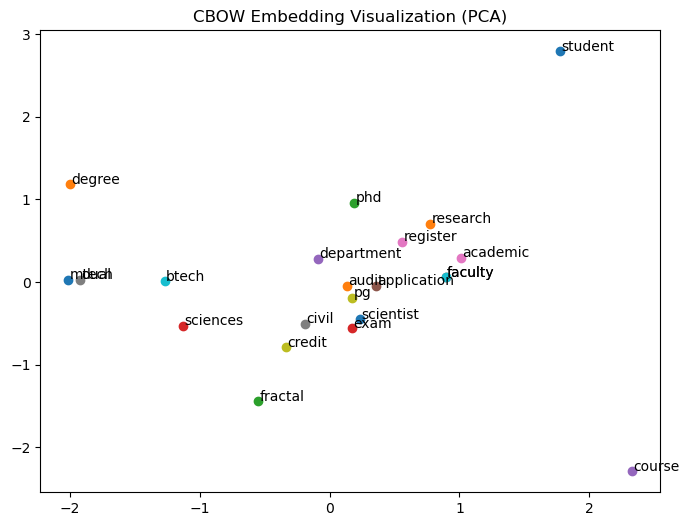

In [190]:
#getting the vectors for CBOW
vectors = []
labels = []

for word in words_to_plot:
    if word in word_to_ix:
        vectors.append(W1[word_to_ix[word]])
        labels.append(word)

#applying PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

# plotting CBOW
plt.figure(figsize=(8,6))

for i, word in enumerate(labels):
    x, y = reduced[i]
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, word)

plt.title("CBOW Embedding Visualization (PCA)")
plt.show()

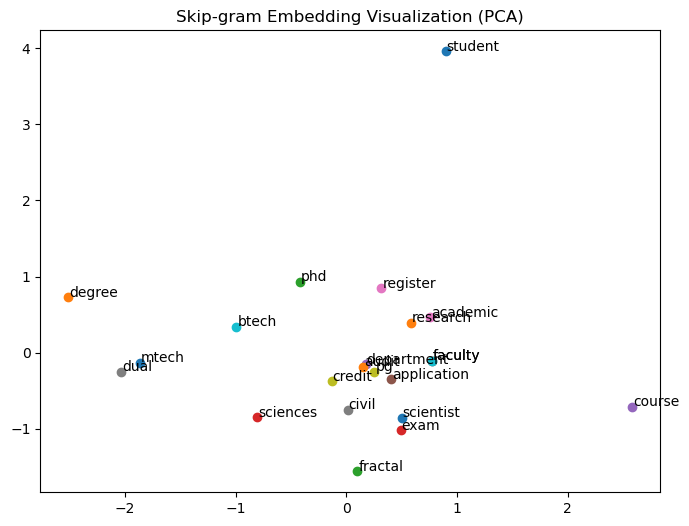

In [191]:
# vectors for Skip-gram
vectors = []
labels = []

for word in words_to_plot:
    if word in word_to_ix:
        vectors.append(W1_sg[word_to_ix[word]])
        labels.append(word)

#Applying PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

#Plotting PCA for Skip-gram
plt.figure(figsize=(8,6))

for i, word in enumerate(labels):
    x, y = reduced[i]
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, word)

plt.title("Skip-gram Embedding Visualization (PCA)")
plt.show()

CBOW shows more borader and smoother clusters. "mtech" and "dual" appear very close, which is true, given the word "dual" always appears after "mtech" in the corpus.

Skpi-gram shows more tighter clusters. The words "mtech" and "dual" appear together but with a little space in Skip-gram. 

"Course" and "student" appear isolated in both CBOW and Skipgram.

The words "credit" and "audit" appear at more distance from each other in CBOW as compared to Skip-gram